In [ ]:
%cp /kaggle/input/datasets/wilaidev/ahahahaha/.env .

# 🚀 Hope ML: Professional Training Pipeline (Kaggle Edition)

This notebook provides a robust, professional environment for training the Hope Trading Transformer. Optimized for **Kaggle**.

### Key Features:
*   **Kaggle Native**: Loads `.env` directly from `/kaggle/working/`.\n
*   **Path Agnostic**: Auto-detects Kaggle Input datasets vs live collection.
*   **Observability**: Real-time TensorBoard monitoring and data distribution plots.
*   **Integrity**: Automatic repo synchronization and dependency validation.

In [1]:
# @title ## 1. Environment & Path Setup
import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = "/kaggle/working/hope"
os.makedirs("/kaggle/working", exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")

# Add to System Path
SCRIPTS_PATH = os.path.join(PROJECT_ROOT, "scripts")
if SCRIPTS_PATH not in sys.path:
    sys.path.insert(0, SCRIPTS_PATH)

print("✅ System path updated.")

📂 Project Root: /kaggle/working/hope
✅ System path updated.


In [15]:
# @title ## 2. Repository Synchronization
REPO_URL = "https://github.com/planetazul3/hope.git" # @param {type:"string"}
BRANCH = "main" # @param {type:"string"}

def sync_repo():
    if not os.path.exists(os.path.join(PROJECT_ROOT, ".git")):
        print(f"Cloning {REPO_URL}...")
        subprocess.check_call(f"git clone --depth 1 {REPO_URL} {PROJECT_ROOT}", shell=True)
    else:
        print(f"Updating repository ({BRANCH})...")
        subprocess.check_call(f"git -C {PROJECT_ROOT} fetch origin", shell=True)
        subprocess.check_call(f"git -C {PROJECT_ROOT} reset --hard origin/{BRANCH}", shell=True)

try:
    sync_repo()
    os.chdir(PROJECT_ROOT)
    print(f"✨ Repository is up to date. Current dir: {os.getcwd()}")
except Exception as e:
    print(f"⚠️ Sync failed: {e}")

Updating repository (main)...
HEAD is now at ba8142b ML: Gracefully handle quantization failures in training pipeline
✨ Repository is up to date. Current dir: /kaggle/working/hope


From https://github.com/planetazul3/hope
   4bbd48a..ba8142b  main       -> origin/main


In [10]:
# @title ## 3. Hardware & Dependency Audit (Transformer-Friendly)

print("📦 Installing modern dependency stack... (This takes a minute)")

!pip install -q "numpy>=2.1,<2.3"
!pip install -q transformers==4.49.0 datasets==3.3.2 accelerate==1.4.0 tokenizers==0.21.0 sentencepiece==0.2.0 evaluate==0.4.3 pandas==2.2.3 scikit-learn==1.6.1 tqdm==4.67.1 matplotlib==3.9.3 seaborn==0.13.2 tensorboard==2.19.0 onnx==1.17.0 onnxruntime-gpu==1.20.1

from IPython.display import clear_output
clear_output()

import platform, subprocess, sys, os

print("✅ Dependencies successfully installed.\n")
print("🔍 Environment Audit:")
print(f"💻 OS: {platform.platform()}")
print(f"🐍 Python: {platform.python_version()}")

try:
    gpu_info = subprocess.check_output(
        "nvidia-smi --query-gpu=name,memory.total,utilization.gpu --format=csv,noheader", 
        shell=True
    ).decode().strip()
    print(f"🚀 GPU Active: {gpu_info}")
except Exception:
    print("❌ PyTorch/nvidia-smi does NOT detect a GPU. Training will be extremely slow.")

print("\n⚠️ CRITICAL STEP REQUIRED ⚠️")
print("If core C-libraries were updated, you must restart the Python engine.")
print("Go to: Run ➡️ Restart Session (or power button at top right)")

✅ Dependencies successfully installed.

🔍 Environment Audit:
💻 OS: Linux-6.6.113+-x86_64-with-glibc2.35
🐍 Python: 3.12.12
🚀 GPU Active: Tesla T4, 15360 MiB, 0 %
Tesla T4, 15360 MiB, 0 %

⚠️ CRITICAL STEP REQUIRED ⚠️
If core C-libraries were updated, you must restart the Python engine.
Go to: Run ➡️ Restart Session (or power button at top right)


In [3]:
# @title ## 4. Credentials & Environment Setup
# @markdown Upload your `.env` file to `/kaggle/working/` and it will be loaded automatically.

import os
import subprocess
import shutil

ENV_PATH = os.path.join(PROJECT_ROOT, ".env")
UPLOADED_ENV_PATH = "/kaggle/working/.env"
EXAMPLE_PATH = os.path.join(PROJECT_ROOT, ".env.example")

# 1. If user uploaded .env to /kaggle/working/, copy it into project root
if os.path.exists(UPLOADED_ENV_PATH) and os.path.abspath(UPLOADED_ENV_PATH) != os.path.abspath(ENV_PATH):
    print("📥 Found uploaded .env in /kaggle/working/. Copying to project root...")
    shutil.copy(UPLOADED_ENV_PATH, ENV_PATH)

# 2. Fallback to .env.example if no .env exists at all
if not os.path.exists(ENV_PATH) and os.path.exists(EXAMPLE_PATH):
    print("⚠️ No .env found. Falling back to .env.example...")
    subprocess.check_call(f"cp {EXAMPLE_PATH} {ENV_PATH}", shell=True)

# 3. Load into current session environment
if os.path.exists(ENV_PATH):
    with open(ENV_PATH, "r") as f:
        for line in f:
            if "=" in line and not line.startswith("#"):
                k, v = line.strip().split("=", 1)
                os.environ[k] = v.strip("\"\'")
    print("✅ Environment configuration synchronized.")
else:
    print("❌ ERROR: No .env configuration could be loaded.")

📥 Found uploaded .env in /kaggle/working/. Copying to project root...
✅ Environment configuration synchronized.


In [16]:
# @title ## 5. Dataset Loading & Tick Collection (Verbose)

import os, sys, subprocess, sqlite3, glob
import pandas as pd

PROJECT_ROOT = "/kaggle/working/hope"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
ENV_PATH  = os.path.join(PROJECT_ROOT, ".env")
SCRIPTS   = os.path.join(PROJECT_ROOT, "scripts")

os.makedirs(DATA_DIR, exist_ok=True)

# --- Extract Symbol ---
SYMBOL = None
if os.path.exists(ENV_PATH):
    print(f"🔍 Reading configuration from {ENV_PATH}...")
    with open(ENV_PATH) as f:
        for line in f:
            line = line.strip()
            if line.startswith("DERIV_SYMBOL="):
                SYMBOL = line.split("=", 1)[1].strip('\'" ')
                break

if not SYMBOL:
    raise RuntimeError("❌ DERIV_SYMBOL not found in .env")
print(f"📌 Target Symbol: {SYMBOL}\n")

DB_PATH  = os.path.join(DATA_DIR, "tick_store.db")
CSV_PATH = os.path.join(DATA_DIR, f"{SYMBOL}_ticks.csv")

# --- Multi-Path Dataset Scanner ---
print("🔍 Scanning for pre-existing datasets...")
SEARCH_DIRS = [
    "/kaggle/input", 
    "/kaggle/working/hope/data", 
    "/content/drive/MyDrive/hope/data"
]

found_csv = None
for search_dir in SEARCH_DIRS:
    if not os.path.exists(search_dir): continue
    for root, dirs, files in os.walk(search_dir):
        for file in files:
            if file.endswith("ticks.csv") and SYMBOL in file:
                found_csv = os.path.join(root, file)
                break
        if found_csv: break
    if found_csv: break

if found_csv:
    print(f"✅ Found Dataset: {found_csv}")
    if os.path.abspath(found_csv) != os.path.abspath(CSV_PATH):
        if os.path.exists(CSV_PATH):
            os.remove(CSV_PATH)
        os.symlink(found_csv, CSV_PATH)
        print(f"🔗 Linked dataset to {CSV_PATH}\n")
    else:
        print("📍 Dataset is already at the target location.\n")
else:
    print("⚠️ No pre-existing dataset found. Proceeding with live Tick Collection...\n")
    
# Check existing CSV for symbol mismatches
if os.path.exists(CSV_PATH) and os.path.getsize(CSV_PATH) > 0:
    try:
        first_row = pd.read_csv(CSV_PATH, header=None, nrows=1)
        if first_row.shape[1] >= 3:
            existing_sym = str(first_row.iloc[0, 0]).strip()
            if existing_sym not in (SYMBOL, "symbol"): 
                print(f"⚠️ Symbol mismatch detected (Found: {existing_sym} | Expected: {SYMBOL}). Wiping {CSV_PATH}...")
                os.remove(CSV_PATH)
            else:
                print(f"✅ Existing CSV symbol matches: {existing_sym}")
    except Exception as e:
        print(f"⚠️ Could not verify CSV symbol: {e}")

# --- REAL-TIME COMMAND STREAMING ---
def run_command_streaming(cmd, desc):
    print(f"\n{'='*50}\n▶ {desc}\n   CMD: {' '.join(cmd)}\n{'-'*50}")
    
    process = subprocess.Popen(
        cmd, cwd=PROJECT_ROOT, stdout=subprocess.PIPE, 
        stderr=subprocess.STDOUT, text=True, bufsize=1
    )
    
    for line in process.stdout:
        print(f"   | {line.strip()}")
        
    process.wait()
    if process.returncode != 0:
        print(f"\n❌ {desc} failed with exit code {process.returncode}")
        raise subprocess.CalledProcessError(process.returncode, cmd)
    print(f"{'-'*50}\n✅ {desc} completed successfully.\n")

# 1. Backfill Database
try:
    run_command_streaming(
        [sys.executable, os.path.join(SCRIPTS, "tick_collector.py"), 
         "--symbol", SYMBOL, "--db", DB_PATH, "--mode", "backfill"], 
        "Fetching missing ticks"
    )
except Exception as e:
    print(f"⚠️ Collector offline or failed. Proceeding with local DB data. Error: {e}\n")

# 2. Export DB -> CSV
try:
    run_command_streaming(
        [sys.executable, os.path.join(SCRIPTS, "export_db.py"), 
         "--db", DB_PATH, "--csv", CSV_PATH, "--symbol", SYMBOL, 
         "--incremental", "--validate"], 
         "Exporting to CSV"
    )
except Exception as e:
    print(f"⚠️ Incremental export failed ({e}). Using chunked SQLite fallback to prevent OOM...")
    conn = sqlite3.connect(DB_PATH)
    chunks = pd.read_sql_query(f"SELECT symbol, epoch, quote FROM ticks WHERE symbol = '{SYMBOL}' ORDER BY epoch", conn, chunksize=500000)
    first_chunk = True
    chunk_count = 0
    for chunk in chunks:
        chunk.to_csv(CSV_PATH, mode='w' if first_chunk else 'a', index=False, header=False)
        first_chunk = False
        chunk_count += 1
        print(f"   ... Processed chunk {chunk_count} ({len(chunk):,} rows)")
    conn.close()
    print(f"✅ Fallback export complete. Total chunks written: {chunk_count}\n")

# ===================== LOAD IN MEMORY ======================
print(f"\n📊 Loading dataset into memory from: {CSV_PATH}")
df_ticks = pd.read_csv(CSV_PATH, header=None, names=["symbol", "epoch", "quote"], on_bad_lines='skip')

if pd.isna(pd.to_numeric(df_ticks['quote'], errors='coerce')).all():
    print("ℹ️ Missing symbol column detected. Re-parsing with 2 columns...")
    df_ticks = pd.read_csv(CSV_PATH, header=None, names=["epoch", "quote"], on_bad_lines='skip')

# Clean and enforce types
df_ticks['epoch'] = pd.to_numeric(df_ticks['epoch'], errors='coerce')
df_ticks['quote'] = pd.to_numeric(df_ticks['quote'], errors='coerce')
initial_len = len(df_ticks)
df_ticks.dropna(subset=['epoch', 'quote'], inplace=True)

if initial_len != len(df_ticks):
    print(f"🧹 Dropped {initial_len - len(df_ticks):,} rows with NaN values (likely CSV headers).")

if df_ticks.empty or (df_ticks["quote"] <= 0).any():
    raise RuntimeError("❌ CSV contains invalid or zero-price data.")

# Display rich statistics
min_date = pd.to_datetime(df_ticks['epoch'].min(), unit='s')
max_date = pd.to_datetime(df_ticks['epoch'].max(), unit='s')
mem_mb = df_ticks.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"\n✅ Dataset Ready!")
print(f"   • Total Ticks: {len(df_ticks):,}")
print(f"   • Date Range:  {min_date} ➔ {max_date}")
print(f"   • Price Range: {df_ticks['quote'].min()} ➔ {df_ticks['quote'].max()}")
print(f"   • RAM Usage:   {mem_mb:.2f} MB")
print("\n🔍 Data Preview (Tail):")
print(df_ticks.tail())

🔍 Reading configuration from /kaggle/working/hope/.env...
📌 Target Symbol: 1HZ75V

🔍 Scanning for pre-existing datasets...
✅ Found Dataset: /kaggle/working/hope/data/1HZ75V_ticks.csv
📍 Dataset is already at the target location.

✅ Existing CSV symbol matches: symbol

▶ Fetching missing ticks
   CMD: /usr/bin/python3 /kaggle/working/hope/scripts/tick_collector.py --symbol 1HZ75V --db /kaggle/working/hope/data/tick_store.db --mode backfill
--------------------------------------------------
   | 2026-04-27 12:10:07,372 [INFO] Collector: Connecting to Deriv (AppID: 1089)...
   | 2026-04-27 12:10:07,761 [INFO] Collector: Connected.
   | 2026-04-27 12:10:07,761 [INFO] Collector: Starting BACKFILL for 1HZ75V from 2026-04-27 11:44:31
   | 2026-04-27 12:10:08,068 [INFO] Collector: [1HZ75V] batch=1 ticks=1536 new=1536 range=[2026-04-27 11:44:32 → 2026-04-27 12:10:07]
   | 2026-04-27 12:10:08,068 [INFO] Collector: Partial batch – caught up to latest.
   | 2026-04-27 12:10:08,068 [INFO] Collector:

📈 Analyzing 93,310 ticks for 1HZ75V...


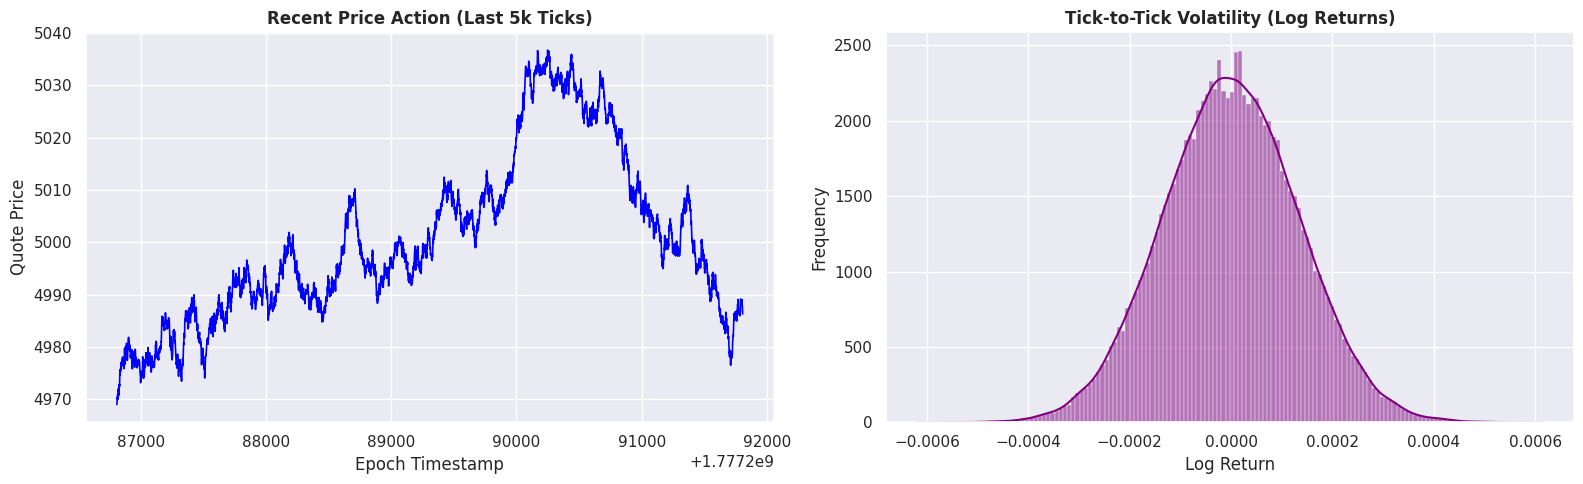


📊 Return Distribution Stats:
Mean: -0.000000 | Std Dev: 0.000134
Skew: 0.0075  | Kurtosis: 0.0140


In [17]:
# @title ## 6. Data Integrity & Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df_ticks' not in locals() or df_ticks.empty:
    raise RuntimeError("❌ df_ticks not found in memory. Run Cell 5 first.")

print(f"📈 Analyzing {len(df_ticks):,} ticks for {SYMBOL}...")

df_clean = df_ticks.drop_duplicates(subset=['epoch']).copy()
dropped = len(df_ticks) - len(df_clean)
if dropped > 0:
    print(f"⚠️ Removed {dropped:,} duplicate epoch entries.")

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tail_data = df_clean.tail(5000)
axes[0].plot(tail_data["epoch"], tail_data["quote"], color='blue', linewidth=1.2)
axes[0].set_title(f"Recent Price Action (Last 5k Ticks)", fontweight='bold')
axes[0].set_xlabel("Epoch Timestamp")
axes[0].set_ylabel("Quote Price")

returns = np.log(df_clean["quote"] / df_clean["quote"].shift(1)).dropna()

sns.histplot(returns, kde=True, bins=150, ax=axes[1], color='purple')
axes[1].set_title("Tick-to-Tick Volatility (Log Returns)", fontweight='bold')
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("\n📊 Return Distribution Stats:")
print(f"Mean: {returns.mean():.6f} | Std Dev: {returns.std():.6f}")
print(f"Skew: {returns.skew():.4f}  | Kurtosis: {returns.kurtosis():.4f}")

In [11]:
%pip install --upgrade scikit-learn scipy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.2 MB/s eta 0:00:0000:010:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that ar

In [12]:
%pip install onnxscript onnx onnxruntime

Note: you may need to restart the kernel to use updated packages.


In [13]:
%pip list

Package                                  Version
---------------------------------------- -------------------
a2a-sdk                                  0.3.25
absl-py                                  1.4.0
accelerate                               1.4.0
access                                   1.1.10.post3
affine                                   2.4.0
aiobotocore                              3.3.0
aiofiles                                 22.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aioitertools                             0.13.0
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                

In [18]:
# @title ## 7. Training & Live Monitoring (Production Aligned)

%load_ext tensorboard

import os, sys, subprocess, traceback, gc
from pathlib import Path

PROJECT_ROOT = "/kaggle/working/hope"
SCRIPTS_DIR  = os.path.join(PROJECT_ROOT, "scripts")
LOG_DIR      = os.path.join(PROJECT_ROOT, "logs")
ENV_PATH     = os.path.join(PROJECT_ROOT, ".env")

os.makedirs(LOG_DIR, exist_ok=True)

if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

os.chdir(PROJECT_ROOT)

SYMBOL = None
if os.path.exists(ENV_PATH):
    with open(ENV_PATH) as f:
        for line in f:
            line = line.strip()
            if line.startswith("DERIV_SYMBOL="):
                SYMBOL = line.split("=", 1)[1].strip('"\' ')
                break

if not SYMBOL:
    SYMBOL = os.environ.get("DERIV_SYMBOL")

if not SYMBOL:
    raise RuntimeError("❌ DERIV_SYMBOL not found in .env. Set it and run Cell 5.")

os.environ["DERIV_SYMBOL"] = SYMBOL
print(f"📌 Training Target: {SYMBOL}")

CSV_PATH = os.path.join(PROJECT_ROOT, "data", f"{SYMBOL}_ticks.csv")
if not os.path.exists(CSV_PATH) or os.path.getsize(CSV_PATH) == 0:
    raise FileNotFoundError(f"❌ Tick data missing or empty at {CSV_PATH}. Run Cell 5.")
print(f"📂 Dataset verified: {CSV_PATH}")

import torch
if torch.cuda.is_available():
    print(f"🚀 Training on GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()
else:
    print("⚠️ WARNING: GPU NOT detected. Training will be extremely slow.")

print(f"📈 Launching TensorBoard logs → {LOG_DIR}")
os.system("pkill -f tensorboard")
%tensorboard --logdir {LOG_DIR}

print("\n🏗️ Starting ML pipeline (Phase 1: TS2Vec, Phase 2: Supervised MTL)")
print("   Architecture: Canonical Causal Transformer (L=32, 8 features)")

try:
    import train_fixed
    
    train_fixed.main(csv_path=CSV_PATH, log_dir=LOG_DIR)
    print("\n✅ Training finished successfully.")

    print("\n📦 Verifying model artifacts in Project Root...")
    artifacts = ["model.onnx", "model.onnx.sig", "best_model.pth"]
    saved_count = 0
    
    for fname in artifacts:
        fpath = os.path.join(PROJECT_ROOT, fname)
        if os.path.exists(fpath):
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"   • Verified: {fname} ({size_mb:.2f} MB)")
            if os.path.abspath(fpath) != os.path.abspath(os.path.join("/kaggle/working/", fname)):
                os.system(f"cp {fpath} /kaggle/working/")
            saved_count += 1
            
    if saved_count == 0:
        print("   ⚠️ No output models found in project root. Did train_fixed fail to export?")
    elif saved_count < len(artifacts):
        print("   ⚠️ Some artifacts are missing. Check logs for quantization or signing errors.")
        
    print("\n✅ Models available in /kaggle/working/ for download.")

except ModuleNotFoundError:
    print("❌ Module `train_fixed` not found in `scripts/`.")
except Exception as e:
    print("❌ Training failed. Traceback:")
    traceback.print_exc()
finally:
    if 'train_fixed' in sys.modules:
        del sys.modules['train_fixed']
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
📌 Training Target: 1HZ75V
📂 Dataset verified: /kaggle/working/hope/data/1HZ75V_ticks.csv
🚀 Training on GPU: Tesla T4
📈 Launching TensorBoard logs → /kaggle/working/hope/logs


<IPython.core.display.Javascript object>

2026-04-27 12:11:22,838 [INFO] TensorBoard logging to: /kaggle/working/hope/logs
2026-04-27 12:11:22,839 [INFO] Loading raw data from: /kaggle/working/hope/data/1HZ75V_ticks.csv
2026-04-27 12:11:23,015 [INFO] Dimensions before sanitization: (93310, 17)



🏗️ Starting ML pipeline (Phase 1: TS2Vec, Phase 2: Supervised MTL)
   Architecture: Canonical Causal Transformer (L=32, 8 features)


2026-04-27 12:11:23,071 [INFO] Dimensions after sanitization: (93251, 17)
2026-04-27 12:11:23,238 [WARNING] Falling back to direct tensor conversion for features.
2026-04-27 12:11:23,284 [INFO] Training on: cuda | Input Dimension: 8
/kaggle/working/hope/scripts/hope_ml/common.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
2026-04-27 12:11:23,291 [INFO] Starting Phase 1: TS2Vec Contrastive Pre-training...
2026-04-27 12:11:33,025 [INFO] Phase 1 Epoch 1, Avg Loss: 4.8542                   
2026-04-27 12:11:42,987 [INFO] Phase 1 Epoch 2, Avg Loss: 4.8532                   
2026-04-27 12:11:52,765 [INFO] Phase 1 Epoch 3, Avg Loss: 4.8533                   
2026-04-27 12:12:02,429 [INFO] Phase 1 Epoch 4, Avg Loss: 4.8534                   
2026-04-27 12:12:12,298 [INFO] Phase 1 Epoch 5, Avg Loss: 4.8532                   
20

[torch.onnx] Obtain model graph for `InferenceModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `InferenceModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
2026-04-27 12:13:13,854 [INFO] No unused functions to remove
2026-04-27 12:13:13,855 [WARNING] The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).
2026-04-27 12:13:13,880 [WARNING] Failed to convert the model to the target version 15 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
 

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


2026-04-27 12:13:14,043 [INFO] Removed 2 unused nodes
2026-04-27 12:13:14,045 [INFO] No unused functions to remove
2026-04-27 12:13:14,050 [INFO] Replaced initializer 'val_31' with existing initializer 'val_26'
2026-04-27 12:13:14,050 [INFO] Replaced initializer 'val_36' with existing initializer 'val_26'
2026-04-27 12:13:14,051 [INFO] Replaced initializer 'val_54' with existing initializer 'val_42'
2026-04-27 12:13:14,052 [INFO] Replaced initializer 'val_97' with existing initializer 'val_95'
2026-04-27 12:13:14,052 [INFO] Replaced initializer 'val_126' with existing initializer 'val_16'
2026-04-27 12:13:14,053 [INFO] Replaced initializer 'val_131' with existing initializer 'val_26'
2026-04-27 12:13:14,054 [INFO] Replaced initializer 'val_136' with existing initializer 'val_26'
2026-04-27 12:13:14,054 [INFO] Replaced initializer 'val_141' with existing initializer 'val_26'
2026-04-27 12:13:14,055 [INFO] Replaced initializer 'val_147' with existing initializer 'val_42'
2026-04-27 12:13


✅ Training finished successfully.

📦 Verifying model artifacts in Project Root...
   • Verified: model.onnx (0.17 MB)
   • Verified: model.onnx.sig (0.00 MB)
   • Verified: best_model.pth (0.42 MB)

✅ Models available in /kaggle/working/ for download.
